# 01 — 세 배치 EDA

`data/archive`의 MATLAB 원본 세 파일을 `src.preprocess`의 공통 로더로 읽습니다.
초기 신호의 통계 계산은 `src.features`와 공유하고, 이 노트북에서 그래프와 해석을 확인합니다.

**실행:** 프로젝트 `.venv` 커널에서 Run All. `01 → 02 → 03` 순서로 분석합니다.
설정·설치는 루트 `README.md`, 원본·품질 기준은 `data/README.md`를 참고하세요.

1. 수명 분포·장단수명 비율·이상치
2. 방전 용량 곡선·열화 속도·탐색적 knee 후보
3. ΔQ(V)와 초기 통계 피처
4. 충전 Policy와 수명·열화의 관계
5. 초기 신호 상관·다중공선성
6. 품질·라벨 민감도 및 배치 간 비교

EDA는 수명 유효 129개(46/39/44)를 먼저 탐색합니다. 모델링 FE 기본 표본은 Batch 3 품질 플래그를
제외한 125개(46/39/40)이므로 두 범위를 구분합니다. 전체 수명 곡선과 knee는 EDA에만 사용합니다.
표·번호별 답변은 `results/eda`, 그래프는 `results/figures/eda`에 저장합니다.


## 0. 환경·파일 경로 설정

현재 폴더 또는 상위 폴더에서 `data/archive`를 찾습니다.
MATLAB v7.3의 HDF5 구조를 `h5py`로 선택적으로 읽어, 지원되지 않는 MATLAB string 메타데이터와 전체 원본 로딩을 피합니다.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p/'src/preprocess.py').is_file() and (p/'data').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('프로젝트 루트 또는 notebooks 폴더에서 실행하세요.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown
for font_path in ['/Library/Fonts/Arial Unicode.ttf',
                  '/System/Library/Fonts/Supplemental/AppleGothic.ttf',
                  'C:/Windows/Fonts/malgun.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf']:
    if Path(font_path).is_file():
        font_manager.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
        break
plt.rcParams.update({'figure.figsize':(12,4.5), 'font.size':11, 'axes.unicode_minus':False,
                     'axes.spines.top':False, 'axes.spines.right':False, 'figure.facecolor':'white'})
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:.4f}')
PALETTE = {1:'#347EA3', 2:'#D46C52', 3:'#168679'}
MODEL_COLORS = {'Ridge':'#347EA3', 'Random Forest':'#168679', 'XGBoost':'#D46C52'}
from scipy.stats import mannwhitneyu
from src.preprocess import get_batch_paths, load_batch, analyze_curves, vif_table
from src.features import prepare_delta_features, add_eda_features, DELTA_FEATURES, CURRENT_FEATURES, BASE_FEATURES, FEATURES
BATCH_PATHS = get_batch_paths(PROJECT_ROOT)
OUTPUT_DIR = PROJECT_ROOT/'results/eda'
print('PROJECT_ROOT:', PROJECT_ROOT)
display(pd.DataFrame([{'batch':b, 'file':p.name, 'size_GiB':p.stat().st_size/1024**3}
                      for b,p in BATCH_PATHS.items()]))
FIGURE_DIR = PROJECT_ROOT/'results/figures/eda'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figure_number = 0
def show_and_save():
    global figure_number
    for number in plt.get_fignums():
        figure_number += 1
        plt.figure(number).savefig(FIGURE_DIR/f'eda_{figure_number:02d}.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close('all')


PROJECT_ROOT: /Users/u079/skala/data-mini-project


,batch,file,size_GiB
0,1,2017-05-12_batchdata_updated_struct_errorcorrect.mat,2.8175
1,2,2018-02-20_batchdata_updated_struct_errorcorrect.mat,1.8837
2,3,2018-04-12_batchdata_updated_struct_errorcorrect.mat,3.0144


### 원본 로더와 품질 기준

- `summary.cycle`의 **실제 라벨**로 10·100사이클의 Qdlin을 선택합니다.
- 초기 전류는 10~100사이클 중 `I>0.1 A`인 구간을 시간 가중 평균합니다.
  양수 시간 간격만 사용하고 `max(1분, 양수 간격 중앙값×10)`보다 긴 기록 공백은 제외합니다.
- `peak_charge_current`는 초기 **각 사이클 최대 전류의 평균**입니다.
- 셀 ID는 파일 안의 **0부터 시작하는 원본 인덱스**입니다.
- Batch 3의 `{2,37,42,43}`은 기존 저자 예제에서 품질 문제가 표시된 ID입니다.
  본 EDA에는 남겨 두고 별도 민감도 분석을 수행합니다.

In [2]:
batch_results = {}
for batch, path in BATCH_PATHS.items():
    print(f'Loading Batch {batch}: {path.name}')
    batch_results[batch] = load_batch(path, batch)
    r = batch_results[batch]
    print(f'  원본 {r["raw_count"]}개 / 수명 유효 {len(r["life"])}개 / 수명 결측 {len(r["excluded"])}개')
    if not r['excluded'].empty:
        display(r['excluded'])
scope = pd.DataFrame([{'batch': b, 'raw_cells': r['raw_count'], 'labelled_cells': len(r['life']),
                       'missing_lifetime': len(r['excluded']),
                       'flagged_quality_cells': int(r['life'].author_quality_flag.sum())}
                      for b, r in batch_results.items()])
display(scope)


Loading Batch 1: 2017-05-12_batchdata_updated_struct_errorcorrect.mat
  원본 46개 / 수명 유효 46개 / 수명 결측 0개
Loading Batch 2: 2018-02-20_batchdata_updated_struct_errorcorrect.mat
  원본 47개 / 수명 유효 39개 / 수명 결측 8개
Loading Batch 3: 2018-04-12_batchdata_updated_struct_errorcorrect.mat
  원본 46개 / 수명 유효 44개 / 수명 결측 2개


,cell_id,reason,recorded_cycles,last_cycle
0,22,Missing cycle_life,920,920
1,23,Missing cycle_life,1152,1152
2,35,Missing cycle_life,423,423
3,36,Missing cycle_life,280,280
4,37,Missing cycle_life,101,101
5,38,Missing cycle_life,101,101
6,39,Missing cycle_life,434,434
7,40,Missing cycle_life,459,459


,cell_id,reason,recorded_cycles,last_cycle
0,23,Missing cycle_life,2189,2189
1,32,Missing cycle_life,2237,2237


,batch,raw_cells,labelled_cells,missing_lifetime,flagged_quality_cells
0,1,46,46,0,0
1,2,47,39,8,0
2,3,46,44,2,4


## 1. Cycle Life 분포는 어떻게 생겼는가?

### 1-1. 동일한 150~2,300사이클 구간의 Histogram
### 1-2. 장수명 `>1,000` / 단수명 `<500`의 개수와 비율
### 1-3. IQR 이상치와 가장 짧은 셀

짧은 수명만으로 오류라고 판단하지 않습니다. 가장 짧은 셀의 Policy·온도·초기 열화는 4절에서 함께 확인합니다.

가장 짧은 셀 5개씩 (원본 cell_id):
IQR 이상치:


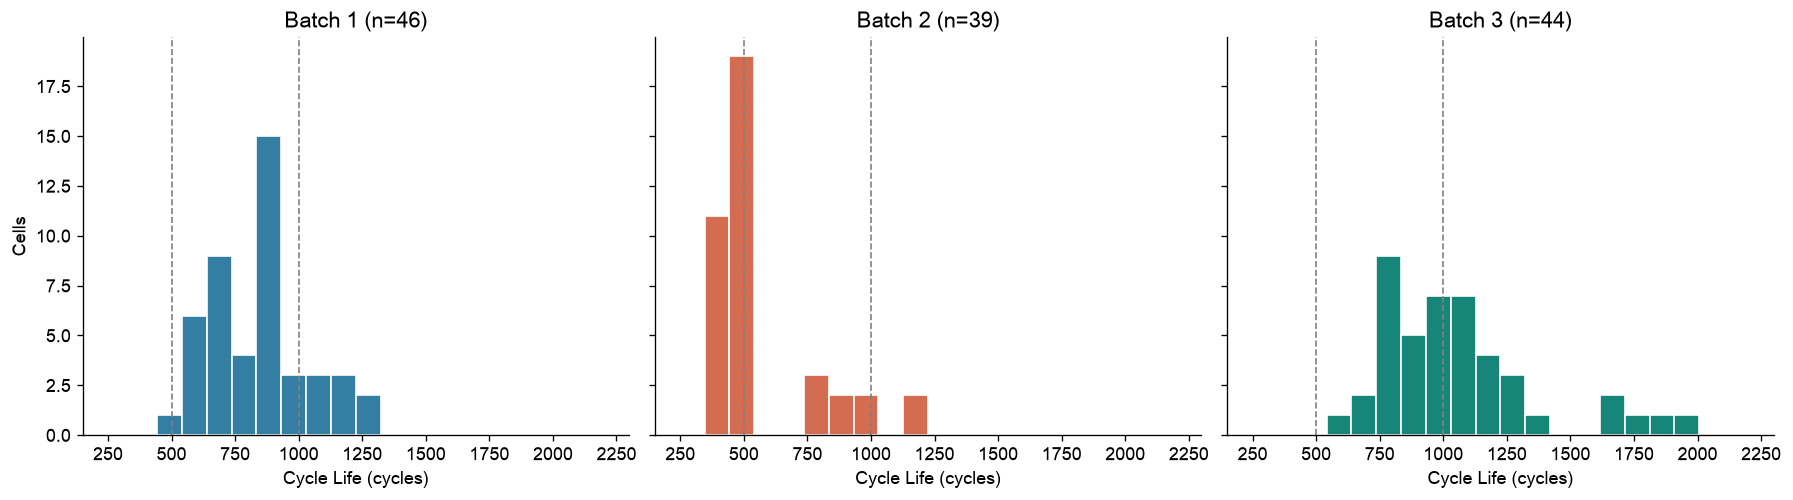

,n,mean,median,minimum,maximum,long_gt_1000,long_pct,short_lt_500,short_pct,IQR_lower,IQR_upper,outliers
batch,,,,,,,,,,,,
1,46,844.7170,858.5000,534,1227,10,21.7390,0,0.0000,386.7500,1230.7500,0
2,39,565.7440,472.0000,392,1186,3,7.6920,28,71.7950,336.0000,612.0000,9
3,44,1059.6590,1005.5000,541,1935,23,52.2730,0,0.0000,337.1250,1646.1250,3


,cell_id,cycle_life,charging_policy,known_collection_issue,author_quality_flag,batch
0,20,534,5.4C(80%)-5.4C,False,False,1
1,21,559,5.4C(80%)-5.4C,False,False,1
2,45,599,8C(35%)-3.6C,False,False,1
3,44,616,8C(35%)-3.6C,False,False,1
4,38,617,7C(40%)-3.6C,False,False,1
5,19,392,6C(60%)-3C,False,False,2
6,6,393,3.6C(9%)-5C,False,False,2
7,15,396,3.6C(9%)-5C,False,False,2
8,21,408,6C(60%)-3C,False,False,2
9,30,412,5.6C(26%)-4.5C,False,False,2


,cell_id,cycle_life,charging_policy,known_collection_issue,author_quality_flag,batch
0,7,777,4.8C(80%)-4.8C-newstructure,False,False,2
1,8,904,5.2C(58%)-4C-newstructure,False,False,2
2,9,791,5.6C(26%)-4.5C-newstructure,False,False,2
3,32,809,4.8C(80%)-4.8C-newstructure,False,False,2
4,33,1140,5.2C(58%)-4C-newstructure,False,False,2
5,34,1186,5.6C(26%)-4.5C-newstructure,False,False,2
6,43,1029,4.8C(80%)-4.8C-newstructure,False,False,2
7,44,841,5.2C(58%)-4C-newstructure,False,False,2
8,45,997,5.6C(26%)-4.5C-newstructure,False,False,2
9,7,1836,4.8C(80%)-4.8C-newstructure,False,False,3


In [3]:
life_rows, shortest_rows, outlier_rows = [], [], []
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharex=True, sharey=True)
bins = np.linspace(150, 2300, 23)
for (batch, r), ax in zip(batch_results.items(), axes):
    life = r['life']; values = life.cycle_life
    q1, q3 = values.quantile([.25, .75])
    lower, upper = q1-1.5*(q3-q1), q3+1.5*(q3-q1)
    r['quartiles'] = (q1, q3)
    r['outliers'] = life.loc[~values.between(lower, upper)].copy()
    outlier_rows.append(r['outliers'].assign(batch=batch))
    shortest_rows.append(life.nsmallest(5, 'cycle_life').assign(batch=batch))
    life_rows.append(dict(batch=batch, n=len(life), mean=values.mean(), median=values.median(),
                          minimum=values.min(), maximum=values.max(),
                          long_gt_1000=int((values > 1000).sum()), long_pct=100*(values > 1000).mean(),
                          short_lt_500=int((values < 500).sum()), short_pct=100*(values < 500).mean(),
                          IQR_lower=lower, IQR_upper=upper, outliers=len(r['outliers'])))
    ax.hist(values, bins=bins, color=PALETTE[batch], edgecolor='white')
    ax.axvline(500, color='gray', ls='--', lw=1)
    ax.axvline(1000, color='gray', ls='--', lw=1)
    ax.set(xlim=(150, 2300), xlabel='Cycle Life (cycles)', title=f'Batch {batch} (n={len(life)})')
axes[0].set_ylabel('Cells')
fig.tight_layout(); show_and_save()
life_summary = pd.DataFrame(life_rows).set_index('batch')
display(life_summary.round(3))
print('가장 짧은 셀 5개씩 (원본 cell_id):')
display(pd.concat(shortest_rows, ignore_index=True))
print('IQR 이상치:')
display(pd.concat(outlier_rows, ignore_index=True))


## 2. 방전 용량은 어떻게 감소하는가?

### 2-1. 사이클별 Qd 곡선
물리적으로 유효한 `0.05~1.5 Ah` 값에 21점 이동 중앙값을 적용합니다. 전체 관측 구간은 EDA에만 사용합니다.

### 2-2. 일정한 열화 vs 가속 열화
관측 구간 앞 30%와 뒤 30%의 선형 기울기를 비교합니다. 뒤 기울기가 더 음수이면 후반 감소가 더 빠릅니다.

### 2-3. Knee point 후보
연속 두 구간 회귀를 관측 구간 **20~80%**에서 탐색합니다.
단일 직선 대비 근사 BIC 개선 `>10`, 두 구간 모두 감소, 후반 감소 기울기가 앞의 2배 이상일 때 후보로 표시합니다.
이는 탐색적 후보이며, 탐색 상한에 걸린 결과는 특히 신중하게 해석합니다.

기울기의 단위는 Ah/cycle입니다. Knee는 탐색 범위와 평활화 방법에 의존하는 후보입니다.


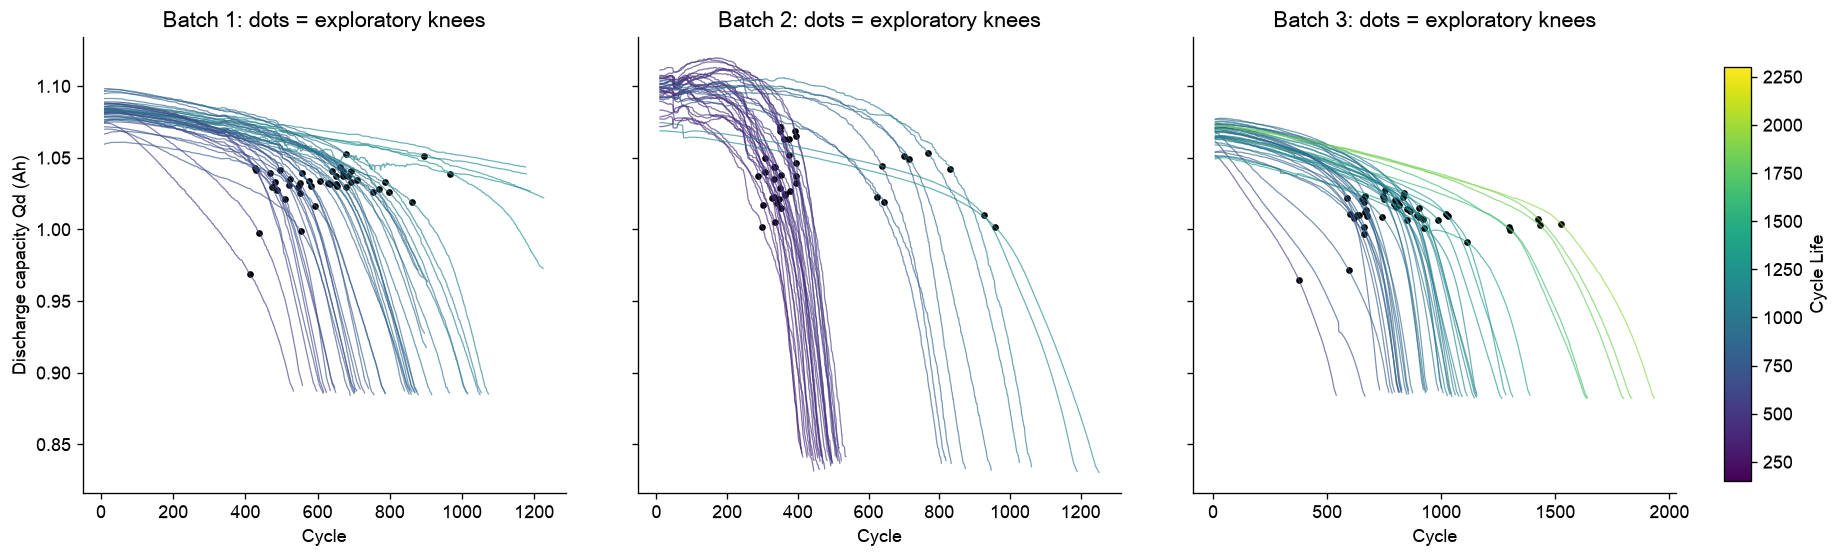

,n,late_steeper,early_slope_median,late_slope_median,knee_candidates,knee_median,knees_at_upper_boundary,endpoint_above_90pct
batch,,,,,,,,
1,46,46,-0.0000,-0.0006,43,627.4545,3,4
2,39,39,0.0000,-0.0015,39,361.6727,2,0
3,44,44,-0.0000,-0.0005,43,802.8000,20,0


In [4]:
curve_summary_rows = []
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
norm = plt.Normalize(150, 2300)
for (batch, r), ax in zip(batch_results.items(), axes):
    r['curves'], r['smooth_curves'] = analyze_curves(r['cells'])
    curves = r['curves']
    for cell in r['cells']:
        x, y = r['smooth_curves'][cell['cell_id']]
        ax.plot(x, y, color=plt.cm.viridis(norm(cell['cycle_life'])), alpha=.65, lw=.75)
        k = curves.set_index('cell_id').loc[cell['cell_id'], 'knee_candidate']
        if np.isfinite(k):
            ax.scatter(k, np.interp(k, x, y), s=9, color='black')
    ax.set(xlabel='Cycle', title=f'Batch {batch}: dots = exploratory knees')
    curve_summary_rows.append(dict(batch=batch, n=len(curves),
                                   late_steeper=int((curves.late_slope < curves.early_slope).sum()),
                                   early_slope_median=curves.early_slope.median(),
                                   late_slope_median=curves.late_slope.median(),
                                   knee_candidates=int(curves.knee_candidate.notna().sum()),
                                   knee_median=curves.knee_candidate.median(),
                                   knees_at_upper_boundary=int(curves.knee_at_upper_boundary.sum()),
                                   endpoint_above_90pct=int((curves.end_capacity_ratio > .9).sum())))
axes[0].set_ylabel('Discharge capacity Qd (Ah)')
fig.subplots_adjust(left=.06, right=.89, bottom=.14, top=.9, wspace=.15)
cax = fig.add_axes([.915, .16, .014, .69])
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), cax=cax, label='Cycle Life')
show_and_save()
curve_summary = pd.DataFrame(curve_summary_rows).set_index('batch')
display(curve_summary)
print('기울기의 단위는 Ah/cycle입니다. Knee는 탐색 범위와 평활화 방법에 의존하는 후보입니다.')


## 3. 초기 ΔQ(V)에서 수명 차이가 보이는가?

### 3-1. ΔQ(V)와 통계 피처
`ΔQ(V) = Q100(V) − Q10(V)`를 동일 전압 격자에서 계산합니다.
분산·`log10(분산)`·최솟값·평균·최댓값·절댓값 면적을 추출합니다.

### 3-2. 장/단수명 곡선 비교
`<500`과 `>1,000` 셀이 모두 존재하면 이 기준을 사용합니다.
그렇지 않은 Batch 1·3은 **해당 배치 수명 하위/상위 사분위**를 명시해서 비교합니다.

### 3-3. 세 배치의 ΔQ log variance–수명 Scatter
배치별 Pearson·Spearman 상관을 계산합니다. 사분위 그룹 검정 p값은 탐색용이며 독립적인 예측 검증이 아닙니다.

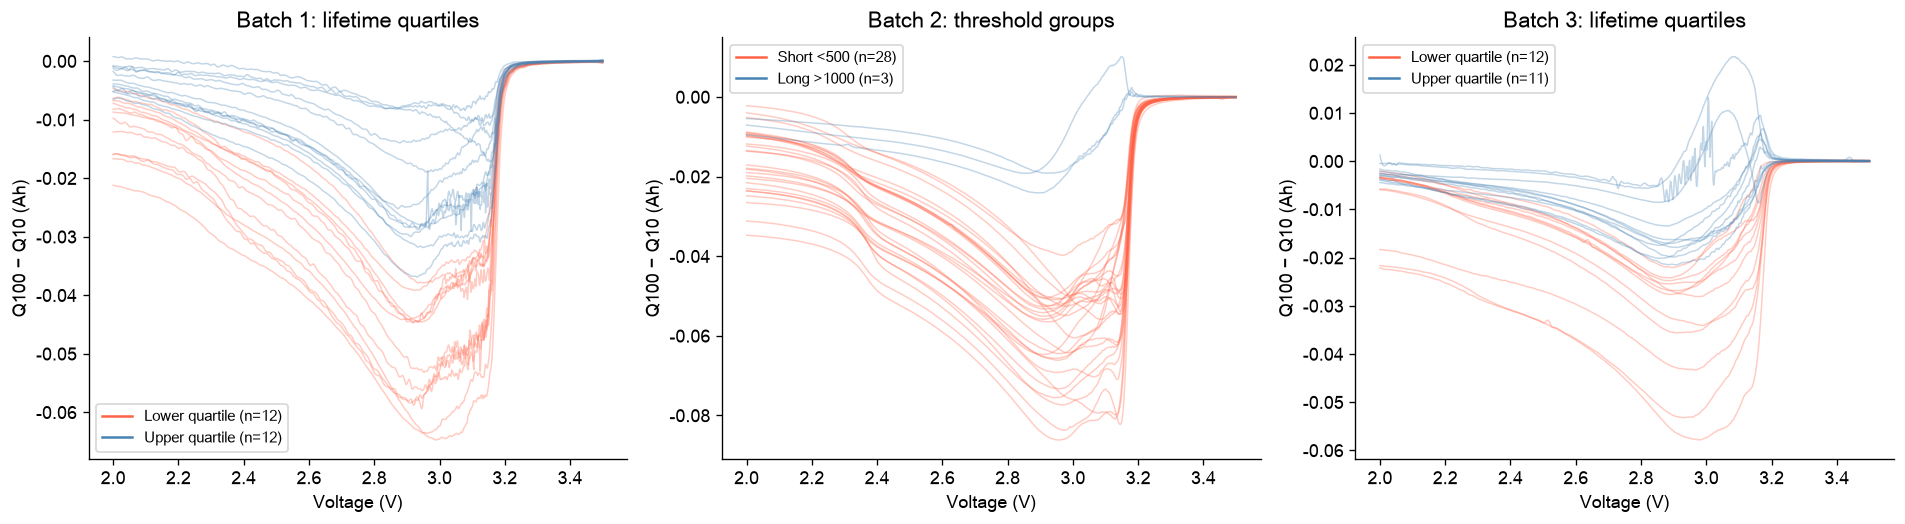

,batch,feature,n,pearson,spearman
0,1,delta_mean,46,0.8538,0.8281
1,1,delta_var,46,-0.8378,-0.8712
2,1,delta_logvar,46,-0.8861,-0.8712
3,1,delta_min,46,0.8816,0.8500
4,1,delta_max,46,0.2639,0.1946
5,1,delta_abs_area,46,-0.8538,-0.8281
6,2,delta_mean,39,0.7671,0.6972
7,2,delta_var,39,-0.7328,-0.7090
8,2,delta_logvar,39,-0.9019,-0.7090
9,2,delta_min,39,0.8185,0.6609


,batch,grouping,group,n,median_life,median_logvar,median_delta_min
0,1,quartile_group,Lower quartile,12,630.5000,-3.5773,-0.0489
1,1,quartile_group,Middle,22,858.5000,-3.9029,-0.0340
2,1,quartile_group,Upper quartile,12,1064.0000,-4.1252,-0.0268
3,2,threshold_group,Long >1000,3,1140.0000,-4.2718,-0.0192
4,2,threshold_group,Middle,8,800.0000,-4.1533,-0.0271
5,2,threshold_group,Short <500,28,449.5000,-3.4461,-0.0562
6,3,quartile_group,Lower quartile,12,804.5000,-4.0791,-0.0279
7,3,quartile_group,Middle,21,1009.0000,-4.1466,-0.0260
8,3,quartile_group,Upper quartile,11,1390.0000,-4.4546,-0.0171


,batch,delta_excluded,exploratory_group_p
0,1,0,0.0000
1,2,0,0.0004
2,3,0,0.0001


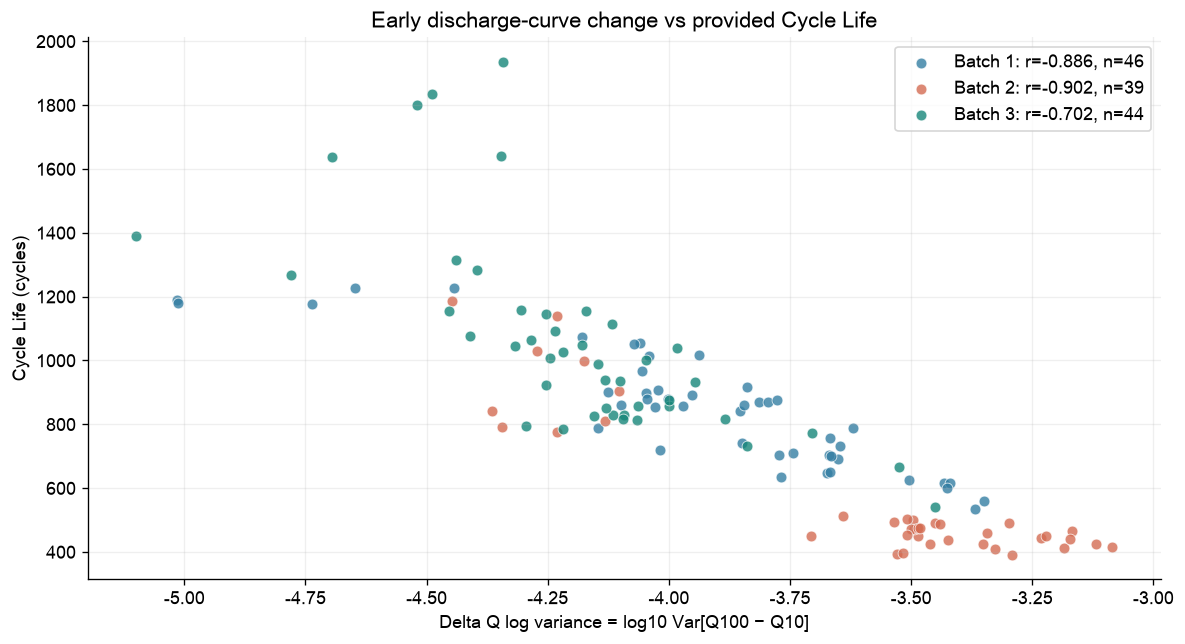

In [5]:
delta_correlation_rows, group_rows = [], []
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for (batch, r), ax in zip(batch_results.items(), axes):
    prepare_delta_features(r)
    delta, delta_curves = r['delta'], r['delta_curves']
    exclusions = r['delta_exclusions'].to_dict('records')
    q1, q3 = r['quartiles']
    delta['quartile_group'] = np.select([delta.cycle_life <= q1, delta.cycle_life >= q3],
                                        ['Lower quartile', 'Upper quartile'], default='Middle')
    delta['threshold_group'] = np.select([delta.cycle_life < 500, delta.cycle_life > 1000],
                                         ['Short <500', 'Long >1000'], default='Middle')
    use_thresholds = (delta.cycle_life < 500).any() and (delta.cycle_life > 1000).any()
    group_col = 'threshold_group' if use_thresholds else 'quartile_group'
    groups = [('Short <500', 'tomato'), ('Long >1000', 'steelblue')] if use_thresholds else [('Lower quartile', 'tomato'), ('Upper quartile', 'steelblue')]
    for label, color in groups:
        ids = delta.loc[delta[group_col] == label, 'cell_id']
        for cid in ids:
            v, d = delta_curves[cid]
            ax.plot(v, d, color=color, alpha=.32, lw=.9)
        ax.plot([], [], color=color, label=f'{label} (n={len(ids)})')
    ax.set(xlabel='Voltage (V)', ylabel='Q100 − Q10 (Ah)',
           title=f'Batch {batch}: {"threshold groups" if use_thresholds else "lifetime quartiles"}')
    ax.legend(fontsize=9)
    r.update(delta=delta, delta_curves=delta_curves,
             delta_exclusions=pd.DataFrame(exclusions, columns=['cell_id', 'reason']))
    for feature in DELTA_FEATURES:
        delta_correlation_rows.append(dict(batch=batch, feature=feature, n=delta[feature].notna().sum(),
                                           pearson=delta[feature].corr(delta.cycle_life),
                                           spearman=delta[feature].corr(delta.cycle_life, method='spearman')))
    for group, part in delta.groupby(group_col):
        group_rows.append(dict(batch=batch, grouping=group_col, group=group, n=len(part),
                               median_life=part.cycle_life.median(), median_logvar=part.delta_logvar.median(),
                               median_delta_min=part.delta_min.median()))
    a = delta.loc[delta[group_col] == groups[0][0], 'delta_logvar']
    b = delta.loc[delta[group_col] == groups[1][0], 'delta_logvar']
    r['delta_group_p'] = mannwhitneyu(a, b, alternative='two-sided').pvalue if len(a) and len(b) else np.nan
fig.tight_layout(); show_and_save()
delta_correlations = pd.DataFrame(delta_correlation_rows)
display(delta_correlations.round(4))
display(pd.DataFrame(group_rows))
display(pd.DataFrame([{'batch': b, 'delta_excluded': len(r['delta_exclusions']),
                       'exploratory_group_p': r['delta_group_p']} for b, r in batch_results.items()]))

fig, ax = plt.subplots(figsize=(10, 5.5))
for batch, r in batch_results.items():
    d = r['delta']; correlation = d.delta_logvar.corr(d.cycle_life)
    ax.scatter(d.delta_logvar, d.cycle_life, color=PALETTE[batch], alpha=.8,
               edgecolors='white', linewidths=.5, s=42,
               label=f'Batch {batch}: r={correlation:.3f}, n={len(d)}')
ax.set(xlabel='Delta Q log variance = log10 Var[Q100 − Q10]', ylabel='Cycle Life (cycles)',
       title='Early discharge-curve change vs provided Cycle Life')
ax.grid(alpha=.2); ax.legend(); fig.tight_layout(); show_and_save()


## 4. 충전 조건과 수명의 관계는?

### 4-1. Policy별 수명 분포·평균·표본 수
Policy는 1차 C-rate / 전환 SOC / 2차 C-rate로 파싱하고, `newstructure`는 원본 라벨로 유지합니다.
표본이 적으므로 개별 셀과 평균을 함께 봅니다.

### 4-2. 고속 충전 셀이 항상 짧은가?
Policy의 C-rate와 **실측 전류(A)**를 구분합니다. 전류만의 상관은 배치마다 다를 수 있습니다.

### 4-3. 전류 패턴과 초기 열화 속도
초기 피처는 10~100사이클에서 계산합니다. IR·온도·충전시간의 비양수 값은 결측 처리하고,
충전시간이 셀 내 중앙값의 5배를 넘으면 기록 이상 후보로 제외합니다.
초기 열화율은 Qd 선형 기울기의 음수입니다. 초기 용량이 증가하면 음수가 될 수 있습니다.

Batch 1: Policy 평균 / 표준편차 / n
Batch 2: Policy 평균 / 표준편차 / n
Batch 3: Policy 평균 / 표준편차 / n
가장 짧은 셀의 초기 조건: 원인 확정이 아니라 비교·추가 점검용입니다.


,mean,std,count
charging_policy,,,
4C(80%)-4C,1226.5000,0.7100,2
3.6C(80%)-3.6C,1182.0000,7.0000,3
4.4C(80%)-4.4C,1074.0000,NaN,1
8C(15%)-3.6C,1008.5000,60.1000,2
5.4C(40%)-3.6C,966.5000,123.7400,2
6C(30%)-3.6C,952.5000,86.9700,2
6C(40%)-3C,935.5000,115.2600,2
5.4C(50%)-3.6C,899.5000,3.5400,2
6C(50%)-3C,888.5000,40.3100,2


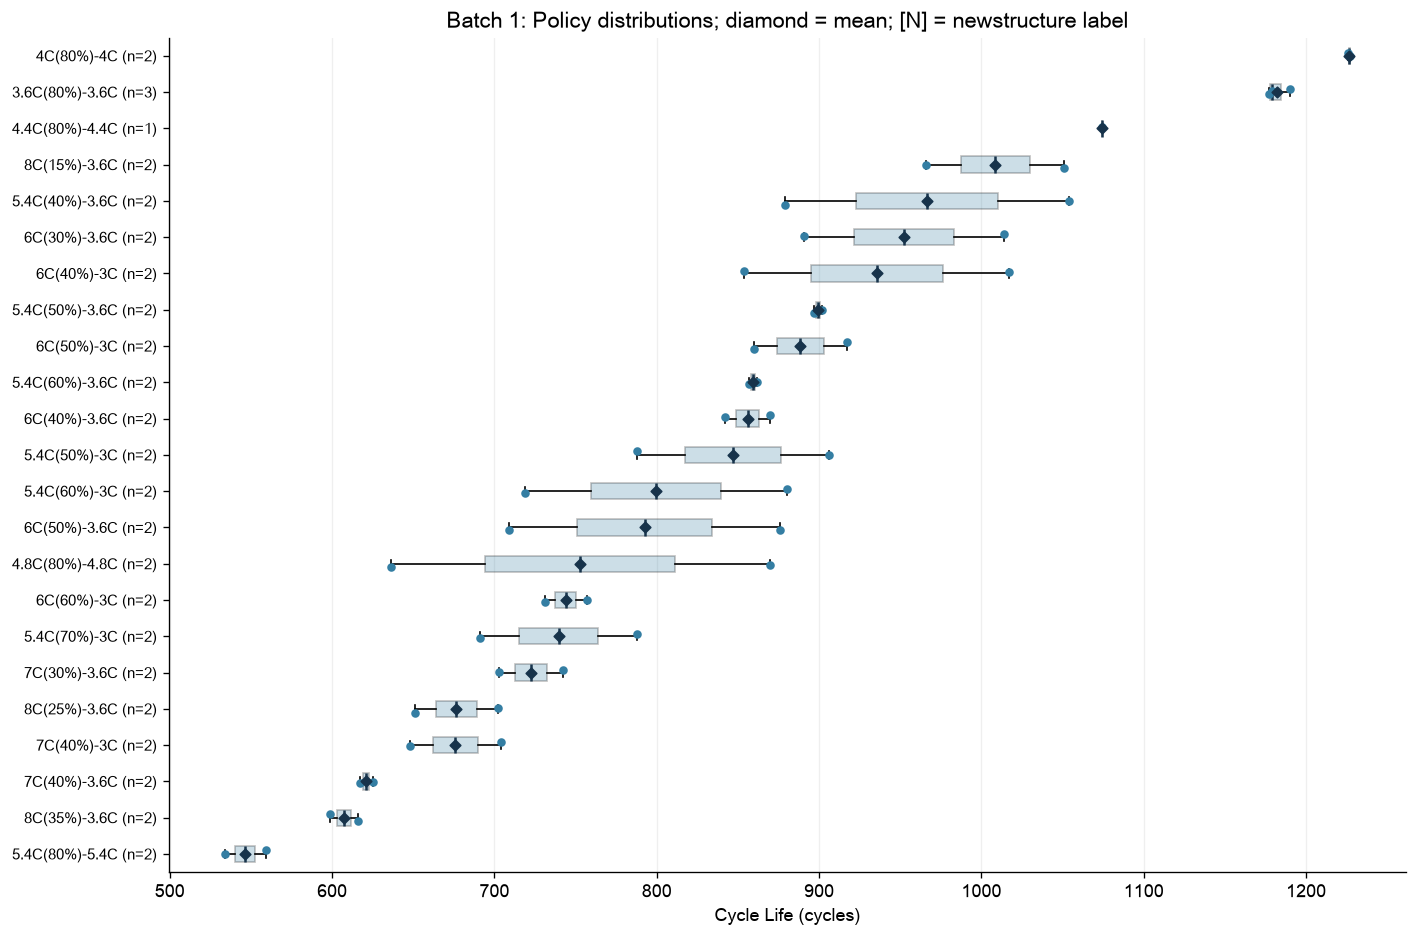

,mean,std,count
charging_policy,,,
5.6C(26%)-4.5C-newstructure,991.3300,197.5600,3
5.2C(58%)-4C-newstructure,961.6700,157.6200,3
4.8C(80%)-4.8C-newstructure,871.6700,137.1900,3
4.8C(80%)-4.8C,483.6000,30.3200,5
4.65C(44%)-5C,482.5000,23.3300,2
5.2C(58%)-4C,477.7500,18.4600,4
5.2C(50%)-4.25C,454.0000,20.9200,5
4.65C(69%)-6C,452.0000,11.3100,2
5.6C(26%)-4.5C,448.5000,29.1300,6


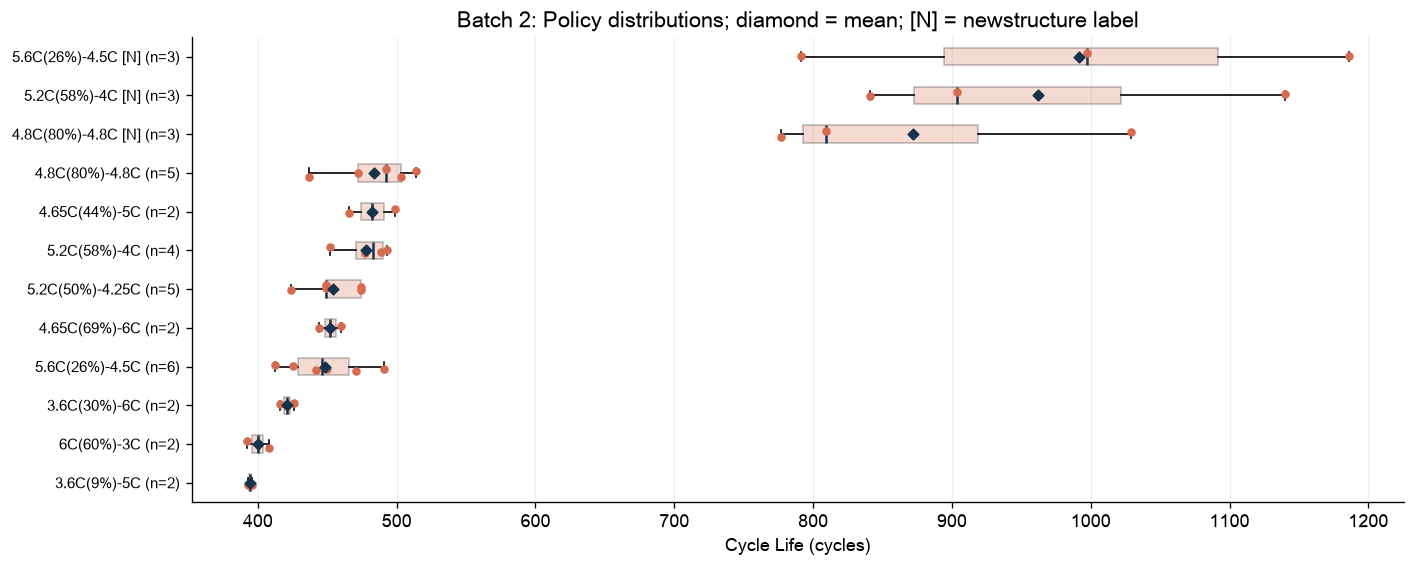

,mean,std,count
charging_policy,,,
4.8C(80%)-4.8C-newstructure,1564.1700,285.7200,6
5C(67%)-4C-newstructure,1105.7100,402.9100,7
5.3C(54%)-4C-newstructure,1074.3800,129.6700,8
5.6C(19%)-4.6C-newstructure,1001.3800,174.5600,8
5.6C(36%)-4.3C-newstructure,930.8800,135.0200,8
5.9C(15%)-4.6C-newstructure,867.0000,12.7300,2
5.9C(60%)-3.1C-newstructure,866.5000,191.6300,2
3.7C(31%)-5.9C-newstructure,660.0000,115.6600,3


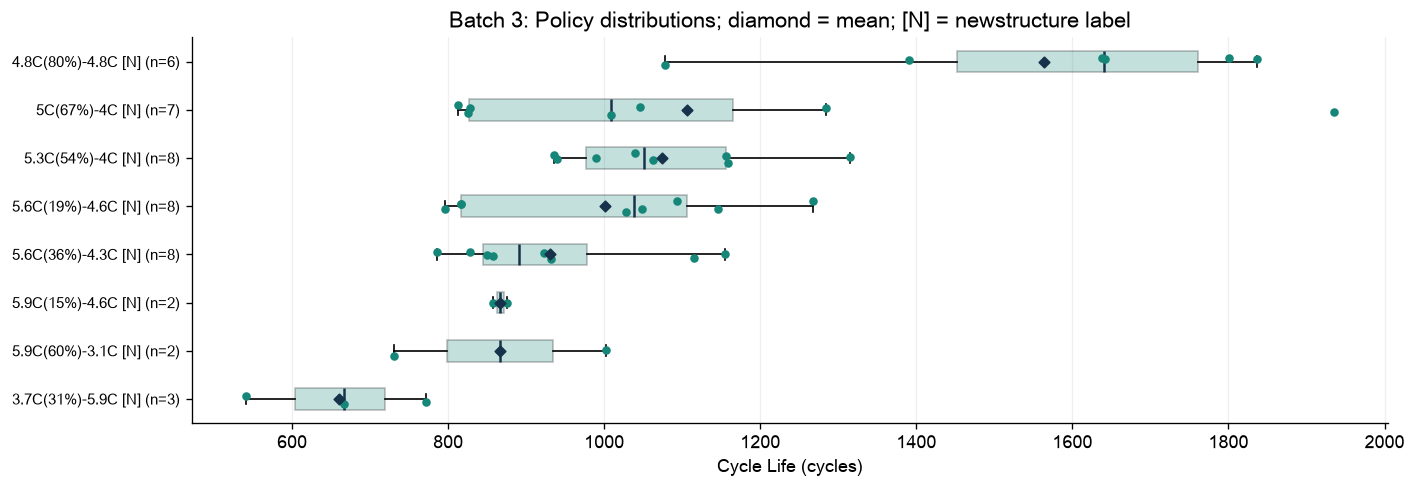

,batch,feature,life_pearson,early_fade_pearson
0,1,mean_charge_current,-0.7720,0.5480
1,1,peak_charge_current,-0.5800,0.1570
2,1,high_current_fraction,0.3870,0.0650
3,1,policy_C1,-0.5800,0.1570
4,1,policy_C2,-0.0960,0.5040
5,1,policy_switch_SOC_pct,0.2350,0.1380
6,2,mean_charge_current,-0.1550,0.0970
7,2,peak_charge_current,-0.1610,0.3740
8,2,high_current_fraction,0.0340,-0.2220
9,2,policy_C1,0.1910,-0.1010


,batch,cell_id,cycle_life,charging_policy,mean_Tavg,mean_charge_current,peak_charge_current,early_fade_rate
20,1,20,534,5.4C(80%)-5.4C,32.1268,2.6269,5.4043,0.0001
21,1,21,559,5.4C(80%)-5.4C,33.1090,2.5849,5.4129,0.0001
45,1,45,599,8C(35%)-3.6C,33.0198,2.4176,8.0077,0.0000
44,1,44,616,8C(35%)-3.6C,32.5678,2.4205,8.0072,0.0000
38,1,38,617,7C(40%)-3.6C,33.7084,2.4720,7.0098,0.0000
19,2,19,392,6C(60%)-3C,32.7725,2.3998,6.0034,-0.0000
6,2,6,393,3.6C(9%)-5C,33.8171,2.3906,4.9996,-0.0001
15,2,15,396,3.6C(9%)-5C,32.8583,2.4337,5.0049,-0.0001
21,2,21,408,6C(60%)-3C,33.6205,2.3954,6.0043,-0.0000
28,2,30,412,5.6C(26%)-4.5C,33.8191,2.9754,5.6043,0.0001


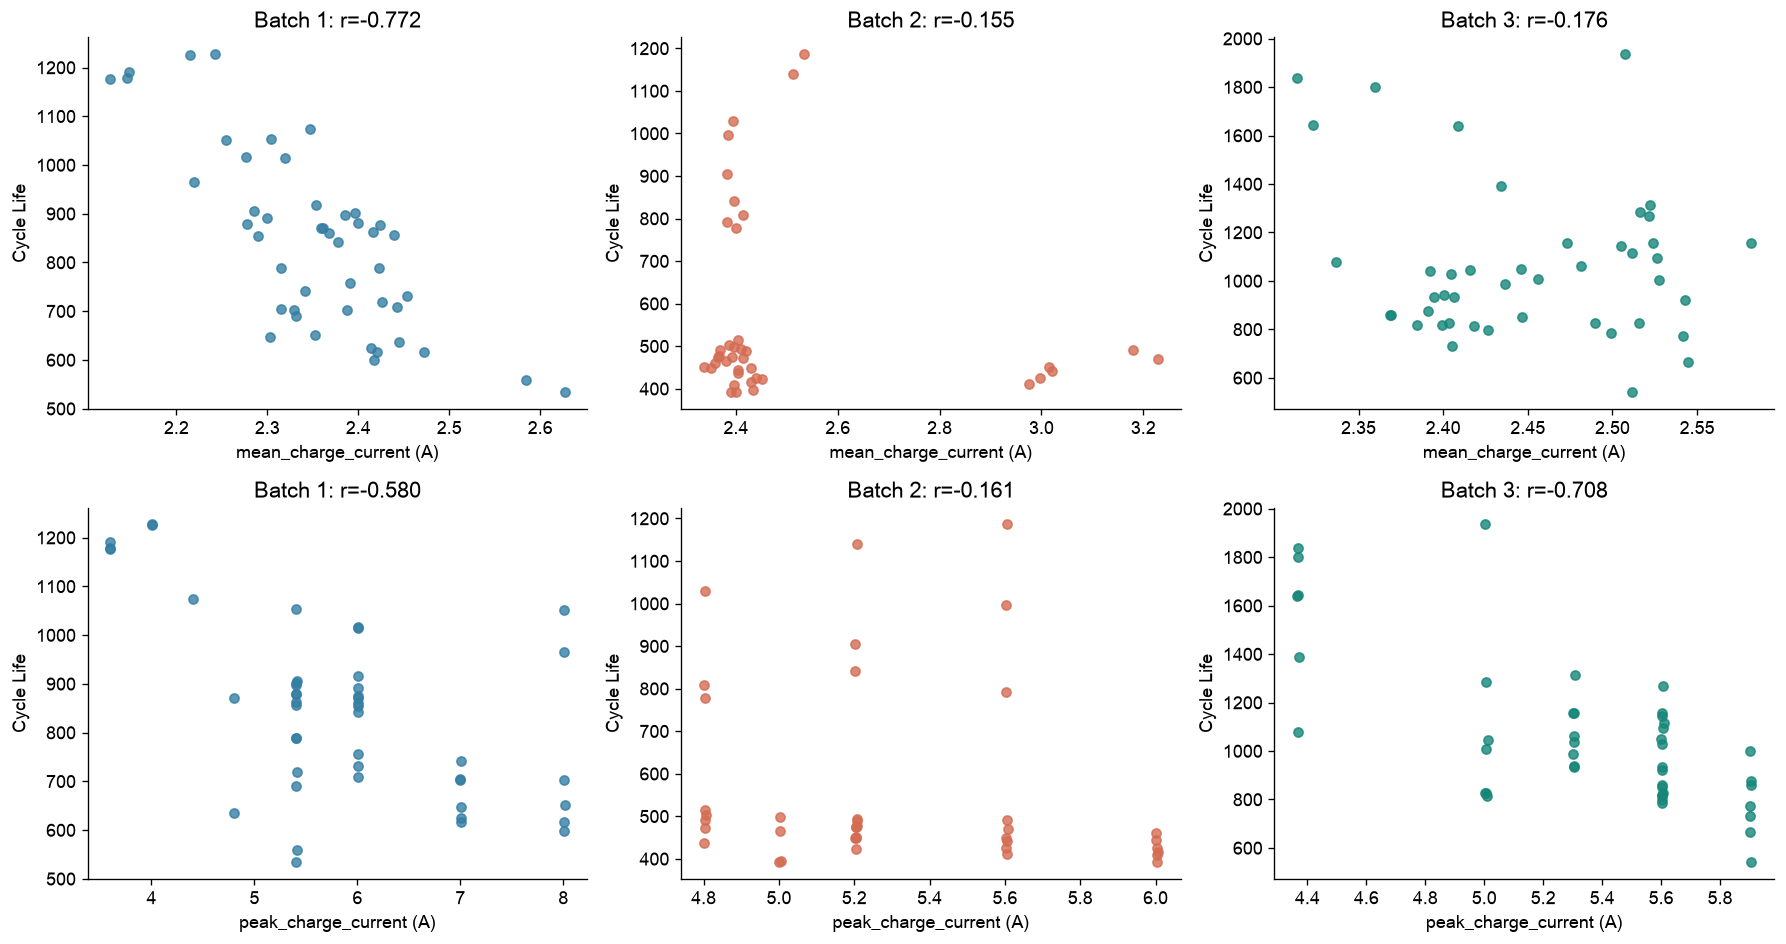

In [6]:
current_correlation_rows, short_detail = [], []
for batch, r in batch_results.items():
    add_eda_features(r)
    early, policy = r['early'], r['policy']
    print(f'Batch {batch}: Policy 평균 / 표준편차 / n')
    display(policy.round(2))
    short_detail.append(early.nsmallest(5, 'cycle_life').assign(batch=batch))
    for feature in CURRENT_FEATURES + ['policy_C1', 'policy_C2', 'policy_switch_SOC_pct']:
        current_correlation_rows.append(dict(batch=batch, feature=feature,
                                             life_pearson=early[feature].corr(early.cycle_life),
                                             early_fade_pearson=early[feature].corr(early.early_fade_rate)))
    order = policy.index[::-1]
    positions = np.arange(len(order))
    values = [early.loc[early.charging_policy == p, 'cycle_life'].to_numpy() for p in order]
    fig, ax = plt.subplots(figsize=(12, max(4.2, .28*len(order)+1.5)))
    boxes = ax.boxplot(values, positions=positions, orientation='horizontal', showfliers=False,
                        patch_artist=True, widths=.45,
                        medianprops={'color': '#17334B', 'linewidth': 1.5})
    for patch in boxes['boxes']:
        patch.set(facecolor=PALETTE[batch], alpha=.25)
    rng = np.random.default_rng(batch)
    for pos, vals in zip(positions, values):
        ax.scatter(vals, pos+rng.uniform(-.12, .12, len(vals)), s=17, color=PALETTE[batch], zorder=3)
        ax.scatter(vals.mean(), pos, marker='D', s=20, color='#17334B', zorder=4)
    labels = [p.replace('-newstructure', ' [N]')+f' (n={int(policy.loc[p, "count"])})' for p in order]
    ax.set_yticks(positions, labels, fontsize=9)
    ax.set(xlabel='Cycle Life (cycles)', title=f'Batch {batch}: Policy distributions; diamond = mean; [N] = newstructure label')
    ax.grid(axis='x', alpha=.2); fig.tight_layout(); show_and_save()

current_correlations = pd.DataFrame(current_correlation_rows)
display(current_correlations.round(3))
print('가장 짧은 셀의 초기 조건: 원인 확정이 아니라 비교·추가 점검용입니다.')
display(pd.concat(short_detail)[['batch', 'cell_id', 'cycle_life', 'charging_policy', 'mean_Tavg',
                                'mean_charge_current', 'peak_charge_current', 'early_fade_rate']])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, (batch, r) in enumerate(batch_results.items()):
    for row, feature in enumerate(['mean_charge_current', 'peak_charge_current']):
        e = r['early']; ax = axes[row, col]
        ax.scatter(e[feature], e.cycle_life, s=30, color=PALETTE[batch], alpha=.8)
        ax.set(xlabel=feature+' (A)', ylabel='Cycle Life',
               title=f'Batch {batch}: r={e[feature].corr(e.cycle_life):.3f}')
fig.tight_layout(); show_and_save()


## 5. 어떤 초기 신호가 수명과 연관되는가?

### 5-1. Pearson·Spearman 상관과 유효 표본 수
피처마다 결측을 제외하는 pairwise 상관이며, 사용한 셀 수를 함께 표시합니다.

### 5-2. 가장 일관된 관계
배치별 순위와 세 배치 공통 피처의 상관을 비교합니다.

### 5-3. 다중공선성
기본 피처의 상관 행렬과 VIF를 확인합니다. VIF는 해당 피처가 모두 존재하는 완전 사례를 사용합니다.
ΔQ 분산·로그분산·면적은 관련 표현이며, 모두 넣는 것이 자동으로 좋은 피처 조합은 아닙니다.

Batch 1: 초기 피처–수명 상관
Batch 1: 기본 피처 VIF
Batch 2: 초기 피처–수명 상관
Batch 2: 기본 피처 VIF
Batch 3: 초기 피처–수명 상관
Batch 3: 기본 피처 VIF
공통 피처 Pearson 비교 / 각 상관계수의 표본 수


,pearson,spearman,n
delta_logvar,-0.8860,-0.8710,46
delta_min,0.8820,0.8500,46
delta_abs_area,-0.8540,-0.8280,46
delta_mean,0.8540,0.8280,46
delta_var,-0.8380,-0.8710,46
mean_charge_current,-0.7720,-0.6880,46
mean_chargetime,0.7390,0.6230,46
peak_charge_current,-0.5800,-0.5150,46
early_fade_rate,-0.5240,-0.5780,46
mean_Tavg,-0.4860,-0.3710,46


,feature,VIF,n,note
0,mean_QD,1.3060,46,
1,std_QD,2.5150,46,
2,mean_IR,1.6380,46,
3,mean_Tavg,16.0740,46,
4,mean_Tmax,14.4680,46,
5,mean_chargetime,1.8100,46,


,pearson,spearman,n
mean_chargetime,-0.9160,-0.7510,39
delta_logvar,-0.9020,-0.7090,39
delta_min,0.8190,0.6610,39
delta_mean,0.7670,0.6970,39
delta_abs_area,-0.7650,-0.6970,39
delta_var,-0.7330,-0.7090,39
mean_IR,-0.6170,-0.1960,33
delta_max,0.4980,0.4080,39
early_fade_rate,0.4840,0.2710,39
mean_Tavg,0.4310,0.1720,39


,feature,VIF,n,note
0,mean_QD,1.7900,33,
1,std_QD,1.1820,33,
2,mean_IR,2.3070,33,
3,mean_Tavg,4.2130,33,
4,mean_Tmax,3.8760,33,
5,mean_chargetime,2.5190,33,


,pearson,spearman,n
peak_charge_current,-0.7080,-0.5670,44
delta_logvar,-0.7020,-0.7970,44
delta_min,0.6920,0.7760,44
delta_mean,0.6390,0.7560,44
mean_chargetime,0.6370,0.2020,44
delta_abs_area,-0.6290,-0.7580,44
delta_var,-0.5900,-0.7970,44
high_current_fraction,0.5040,0.5240,44
delta_max,0.4080,0.2600,44
early_fade_rate,-0.3610,-0.1840,44


,feature,VIF,n,note
0,mean_QD,1.6650,44,
1,std_QD,2.5650,44,
2,mean_IR,2.1260,44,
3,mean_Tavg,19.8560,44,
4,mean_Tmax,19.3250,44,
5,mean_chargetime,1.0730,44,


batch,1,2,3
feature,,,
delta_logvar,-0.8860,-0.9020,-0.7020
delta_min,0.8820,0.8190,0.6920
mean_chargetime,0.7390,-0.9160,0.6370
mean_charge_current,-0.7720,-0.1550,-0.1760
peak_charge_current,-0.5800,-0.1610,-0.7080
mean_Tavg,-0.4860,0.4310,-0.0210
mean_Tmax,-0.4070,0.0190,-0.1060
mean_IR,0.2310,-0.6170,0.1880


batch,1,2,3
feature,,,
delta_logvar,46,39,44
delta_min,46,39,44
mean_chargetime,46,39,44
mean_charge_current,46,39,44
peak_charge_current,46,39,44
mean_Tavg,46,39,44
mean_Tmax,46,39,44
mean_IR,46,33,44


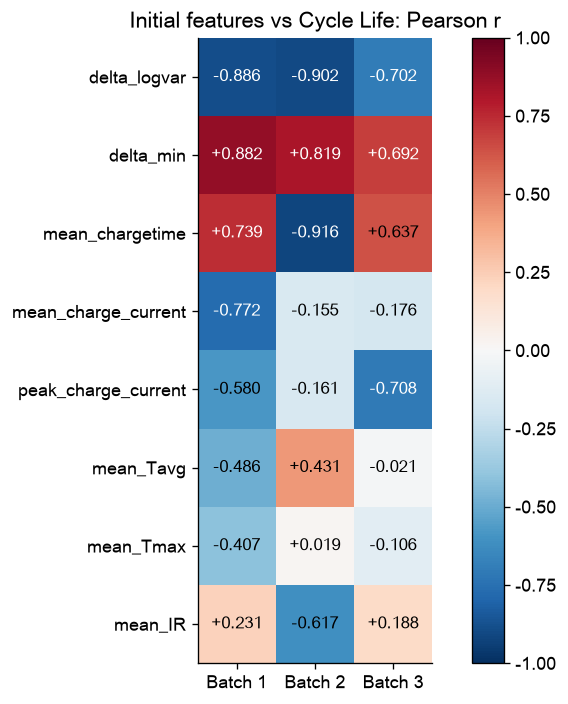

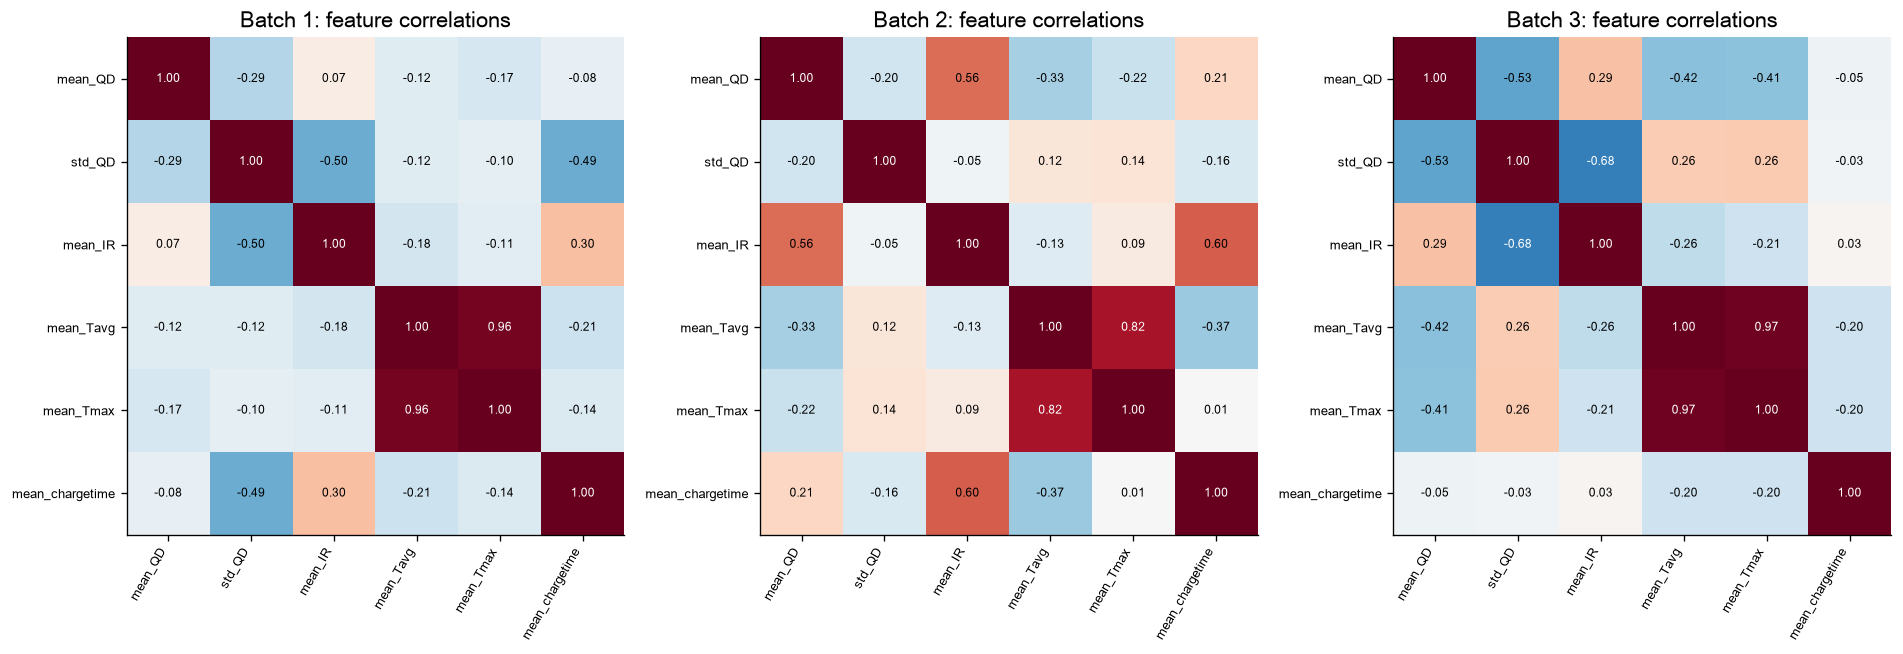

In [7]:
ranking_parts = []
for batch, r in batch_results.items():
    e = r['early']
    ranking = pd.DataFrame({method: e[FEATURES+['cycle_life']].corr(method=method)['cycle_life'].drop('cycle_life')
                            for method in ['pearson', 'spearman']})
    ranking['n'] = e[FEATURES].notna().sum()
    ranking = ranking.loc[ranking.pearson.abs().sort_values(ascending=False).index]
    r['ranking'] = ranking
    r['vif'] = vif_table(e[BASE_FEATURES])
    ranking_parts.append(ranking.reset_index(names='feature').assign(batch=batch))
    print(f'Batch {batch}: 초기 피처–수명 상관')
    display(ranking.round(3))
    print(f'Batch {batch}: 기본 피처 VIF')
    display(r['vif'].round(3))
all_rankings = pd.concat(ranking_parts, ignore_index=True)
selected = ['delta_logvar', 'delta_min', 'mean_chargetime', 'mean_charge_current',
            'peak_charge_current', 'mean_Tavg', 'mean_Tmax', 'mean_IR']
pearson_compare = all_rankings.pivot(index='feature', columns='batch', values='pearson').reindex(selected)
spearman_compare = all_rankings.pivot(index='feature', columns='batch', values='spearman').reindex(selected)
correlation_n = all_rankings.pivot(index='feature', columns='batch', values='n').reindex(selected)
print('공통 피처 Pearson 비교 / 각 상관계수의 표본 수')
display(pearson_compare.round(3)); display(correlation_n)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(pearson_compare, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(3), ['Batch 1', 'Batch 2', 'Batch 3'])
ax.set_yticks(range(len(selected)), selected)
for i in range(len(selected)):
    for j in range(3):
        value = pearson_compare.iloc[i, j]
        ax.text(j, i, f'{value:+.3f}', ha='center', va='center', fontsize=10,
                color='white' if abs(value) > .65 else 'black')
ax.set_title('Initial features vs Cycle Life: Pearson r')
fig.colorbar(im, ax=ax); fig.tight_layout(); show_and_save()

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for (batch, r), ax in zip(batch_results.items(), axes):
    matrix = r['early'][BASE_FEATURES].corr()
    im = ax.imshow(matrix, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(BASE_FEATURES)), BASE_FEATURES, rotation=60, ha='right', fontsize=8)
    ax.set_yticks(range(len(BASE_FEATURES)), BASE_FEATURES, fontsize=8)
    for i in range(len(BASE_FEATURES)):
        for j in range(len(BASE_FEATURES)):
            value = matrix.iloc[i, j]
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(value) > .65 else 'black')
    ax.set_title(f'Batch {batch}: feature correlations')
fig.tight_layout(); show_and_save()


## 6. 품질·교란 요인·수명 라벨 점검

### 6-1. Batch 3 품질 플래그 제외 전후
기본 44셀, 수집 문제 ID 37만 제외한 43셀, 전체 플래그 4개를 제외한 40셀을 비교합니다.

### 6-2. Policy / 원본 라벨 그룹 안에서도 상관이 유지되는가?
Policy별 평균을 빼고 상관을 계산하며, Batch 2의 `newstructure` 그룹을 분리해 봅니다.
이는 간단한 기술적 민감도 분석이며 인과 추정이 아닙니다.

### 6-3. 기록 종료와 EOL은 같은가?
마지막 Qd·관측 사이클·제공 수명 라벨을 비교합니다. **0.885 Ah 초과**는 종단 확인 후보 기준이며,
개별 셀의 진짜 80% SOH 여부를 판정하는 일반 기준은 아닙니다.
원본 데이터의 약 0.88 Ah 종단 convention과 초기 용량 대비 비율을 구분합니다.

In [8]:
sensitivity_features = ['delta_logvar', 'delta_min', 'mean_chargetime', 'mean_charge_current',
                        'peak_charge_current', 'mean_IR', 'mean_Tavg']
b3 = batch_results[3]['early']
b3_masks = {'All labelled (44)': np.ones(len(b3), dtype=bool),
            'Exclude collection issue (43)': ~b3.known_collection_issue,
            'Exclude all quality flags (40)': ~b3.author_quality_flag}
b3_sensitivity = pd.DataFrame({label: b3.loc[mask, sensitivity_features+['cycle_life']].corr()['cycle_life'].drop('cycle_life')
                               for label, mask in b3_masks.items()})
print('Batch 3 품질 민감도: Pearson')
display(b3_sensitivity.round(3))

within_policy_rows, structure_rows, charge_cleaning_rows = [], [], []
within_features = ['peak_charge_current', 'mean_charge_current', 'mean_chargetime', 'delta_logvar']
for batch, r in batch_results.items():
    e = r['early']
    cols = ['cycle_life']+within_features
    centered = e[cols] - e.groupby('charging_policy')[cols].transform('mean')
    for feature in within_features:
        within_policy_rows.append(dict(batch=batch, feature=feature,
                                        pooled_pearson=e[feature].corr(e.cycle_life),
                                        policy_centered_pearson=centered[feature].corr(centered.cycle_life)))
    for label, group in e.groupby('structure_group'):
        structure_rows.append(dict(batch=batch, label_group=label, n=len(group), mean_life=group.cycle_life.mean(),
                                    delta_logvar_r=group.delta_logvar.corr(group.cycle_life),
                                    charge_time_r=group.mean_chargetime.corr(group.cycle_life)))
    charge_cleaning_rows.append(dict(batch=batch, removed_time_gaps=int(r['quality'].time_gap_intervals.sum()),
                                      removed_charge_spikes=int(r['quality'].charge_time_spikes.sum()),
                                      raw_chargetime_r=e.raw_mean_chargetime.corr(e.cycle_life),
                                      cleaned_chargetime_r=e.mean_chargetime.corr(e.cycle_life),
                                      median_chargetime_r=e.median_chargetime.corr(e.cycle_life)))
within_policy = pd.DataFrame(within_policy_rows)
structure_summary = pd.DataFrame(structure_rows)
print('전체 상관 vs Policy 평균 제거 후 상관')
display(within_policy.round(3))
print('원본 라벨 그룹: 의미를 물리적 구조로 임의 해석하지 않습니다.')
display(structure_summary.round(3))
print('초기 시간·충전시간 정제 민감도')
display(pd.DataFrame(charge_cleaning_rows).round(3))

endpoint_audit = pd.concat([r['endpoint'] for r in batch_results.values()], ignore_index=True)
endpoint_summary = endpoint_audit.groupby('batch').agg(
    n=('cell_id', 'size'), endpoint_review_candidates=('endpoint_review_candidate', 'sum'),
    min_record_minus_life=('recorded_minus_life', 'min'),
    max_record_minus_life=('recorded_minus_life', 'max'),
    observed_QD_0_88_crossings=('first_cycle_QD_le_0_88', 'count'))
display(endpoint_summary)
print('종단 확인 후보: 제공된 수명을 임의로 재계산하거나 자동 삭제하지 않습니다.')
display(endpoint_audit.loc[endpoint_audit.endpoint_review_candidate])


Batch 3 품질 민감도: Pearson
전체 상관 vs Policy 평균 제거 후 상관
원본 라벨 그룹: 의미를 물리적 구조로 임의 해석하지 않습니다.
초기 시간·충전시간 정제 민감도
종단 확인 후보: 제공된 수명을 임의로 재계산하거나 자동 삭제하지 않습니다.


,All labelled (44),Exclude collection issue (43),Exclude all quality flags (40)
delta_logvar,-0.7020,-0.7200,-0.7420
delta_min,0.6920,0.6820,0.6650
mean_chargetime,0.6370,0.6310,0.5970
mean_charge_current,-0.1760,-0.1730,-0.1180
peak_charge_current,-0.7080,-0.7010,-0.6910
mean_IR,0.1880,0.2150,0.2000
mean_Tavg,-0.0210,-0.0380,-0.0400


,batch,feature,pooled_pearson,policy_centered_pearson
0,1,peak_charge_current,-0.5800,0.0530
1,1,mean_charge_current,-0.7720,-0.2300
2,1,mean_chargetime,0.7390,-0.0580
3,1,delta_logvar,-0.8860,-0.0720
4,2,peak_charge_current,-0.1610,0.4090
5,2,mean_charge_current,-0.1550,0.4720
6,2,mean_chargetime,-0.9160,-0.0460
7,2,delta_logvar,-0.9020,-0.1970
8,3,peak_charge_current,-0.7080,-0.0450
9,3,mean_charge_current,-0.1760,0.4130


,batch,label_group,n,mean_life,delta_logvar_r,charge_time_r
0,1,Other labelled protocols,46,844.7170,-0.8860,0.7390
1,2,Other labelled protocols,30,453.0000,-0.3860,-0.2670
2,2,newstructure label,9,941.5560,-0.2940,0.1470
3,3,newstructure label,44,1059.6590,-0.7020,0.6370


,batch,removed_time_gaps,removed_charge_spikes,raw_chargetime_r,cleaned_chargetime_r,median_chargetime_r
0,1,59,3,0.5560,0.7390,0.7450
1,2,39,10,0.0870,-0.9160,-0.9160
2,3,1,0,0.6370,0.6370,0.6380


,n,endpoint_review_candidates,min_record_minus_life,max_record_minus_life,observed_QD_0_88_crossings
batch,,,,,
1,46,10,-1,-1,0
2,39,0,15,66,39
3,44,0,-1,-1,0


,batch,cell_id,provided_life,last_cycle,recorded_minus_life,last_QD,last_to_initial_ratio,first_cycle_QD_le_0_88,endpoint_review_candidate
0,1,0,1190,1189,-1,1.0262,0.9534,NaN,True
1,1,1,1179,1178,-1,1.0382,0.9596,NaN,True
2,1,2,1177,1176,-1,1.0433,0.9610,NaN,True
3,1,3,1226,1225,-1,0.9709,0.8949,NaN,True
4,1,4,1227,1226,-1,1.0220,0.9439,NaN,True
8,1,8,879,878,-1,0.9690,0.8849,NaN,True
10,1,10,906,905,-1,0.9610,0.8884,NaN,True
12,1,12,902,901,-1,0.9131,0.8438,NaN,True
13,1,13,897,896,-1,0.9231,0.8512,NaN,True
22,1,22,891,890,-1,0.9633,0.8890,NaN,True


## 7. 세 배치 EDA 비교

처리 기준을 동일하게 적용한 수명·열화·초기 신호를 한 표로 비교합니다.
동일 명목 Policy에서도 배치·라벨 그룹의 평균이 달라질 수 있습니다.

In [9]:
batch_comparison = scope.set_index('batch').join(life_summary.drop(columns='n')).join(curve_summary.drop(columns='n'))
batch_comparison['policies'] = [r['life'].charging_policy.nunique() for r in batch_results.values()]
batch_comparison['delta_logvar_pearson'] = pearson_compare.loc['delta_logvar']
batch_comparison['delta_logvar_spearman'] = spearman_compare.loc['delta_logvar']
batch_comparison['temperature_r'] = [r['early'].mean_Tavg.corr(r['early'].mean_Tmax) for r in batch_results.values()]
display(batch_comparison.round(3))

same_policy_rows = []
for batch, r in batch_results.items():
    matched = r['policy'].loc[r['policy'].index.str.startswith('4.8C(80%)-4.8C')]
    for label, row in matched.iterrows():
        same_policy_rows.append(dict(batch=batch, policy=label, mean_life=row['mean'], n=int(row['count'])))
matched_policy = pd.DataFrame(same_policy_rows)
print('동일 명목 Policy: 4.8C(80%)-4.8C (라벨·배치 구분)')
display(matched_policy.round(2))

# 모델링 후보 표본 125개 및 종단 확인 후보를 제외한 보수적 표본은 기본 EDA와 분리합니다.
pooled_early = pd.concat([r['early'].assign(batch=batch) for batch, r in batch_results.items()], ignore_index=True)
quality_model_candidates = pooled_early.loc[~pooled_early.author_quality_flag].copy()
audit_keys = set(zip(endpoint_audit.loc[endpoint_audit.endpoint_review_candidate, 'batch'],
                     endpoint_audit.loc[endpoint_audit.endpoint_review_candidate, 'cell_id']))
conservative_mask = [((int(row.batch), int(row.cell_id)) not in audit_keys)
                     for row in quality_model_candidates.itertuples()]
conservative_candidates = quality_model_candidates.loc[conservative_mask].copy()
sample_scopes = pd.DataFrame([
    {'scope': 'Main EDA: retain all labelled', 'n': len(pooled_early)},
    {'scope': 'Exclude Batch3 author quality flags', 'n': len(quality_model_candidates)},
    {'scope': 'Also exclude endpoint review candidates (sensitivity only)', 'n': len(conservative_candidates)},
])
display(sample_scopes)
print('종단 확인 후보 제외 민감도: 배치별 ΔQ log variance Pearson')
display(pd.DataFrame([{'batch': batch, 'n': len(part),
                       'pearson': part.delta_logvar.corr(part.cycle_life)}
                      for batch, part in conservative_candidates.groupby('batch')]))


동일 명목 Policy: 4.8C(80%)-4.8C (라벨·배치 구분)
종단 확인 후보 제외 민감도: 배치별 ΔQ log variance Pearson


,raw_cells,labelled_cells,missing_lifetime,flagged_quality_cells,mean,median,minimum,maximum,long_gt_1000,long_pct,short_lt_500,short_pct,IQR_lower,IQR_upper,outliers,late_steeper,early_slope_median,late_slope_median,knee_candidates,knee_median,knees_at_upper_boundary,endpoint_above_90pct,policies,delta_logvar_pearson,delta_logvar_spearman,temperature_r
batch,,,,,,,,,,,,,,,,,,,,,,,,,,
1,46,46,0,0,844.7170,858.5000,534,1227,10,21.7390,0,0.0000,386.7500,1230.7500,0,46,-0.0000,-0.0010,43,627.4550,3,4,23,-0.8860,-0.8710,0.9560
2,47,39,8,0,565.7440,472.0000,392,1186,3,7.6920,28,71.7950,336.0000,612.0000,9,39,0.0000,-0.0010,39,361.6730,2,0,12,-0.9020,-0.7090,0.8220
3,46,44,2,4,1059.6590,1005.5000,541,1935,23,52.2730,0,0.0000,337.1250,1646.1250,3,44,-0.0000,-0.0000,43,802.8000,20,0,8,-0.7020,-0.7970,0.9710


,batch,policy,mean_life,n
0,1,4.8C(80%)-4.8C,753.0000,2
1,2,4.8C(80%)-4.8C-newstructure,871.6700,3
2,2,4.8C(80%)-4.8C,483.6000,5
3,3,4.8C(80%)-4.8C-newstructure,1564.1700,6


,scope,n
0,Main EDA: retain all labelled,129
1,Exclude Batch3 author quality flags,125
2,Also exclude endpoint review candidates (sensitivity only),115


,batch,n,pearson
0,1,36,-0.8266
1,2,39,-0.9019
2,3,40,-0.7417


## 8. 번호별 답변 — 실제 계산 결과 요약

아래 답변은 앞 셀에서 계산한 표를 사용해 생성합니다. 원인·인과 효과나 모델의 예측 성능이 검증되었다고 해석하지 않습니다.

In [10]:
lines = ['## 1. Cycle Life 분포', '', '**1-1. 분포**']
for batch, row in life_summary.iterrows():
    lines.append(f'- Batch {batch}: n={int(row.n)}, 범위 {row.minimum:.0f}~{row.maximum:.0f}, 평균 {row["mean"]:.1f}, 중앙값 {row["median"]:.1f}.')
lines += ['', '**1-2. 장/단수명 비율**']
for batch, row in life_summary.iterrows():
    lines.append(f'- Batch {batch}: >1,000은 {int(row.long_gt_1000)}개({row.long_pct:.1f}%), <500은 {int(row.short_lt_500)}개({row.short_pct:.1f}%).')
lines += ['', '**1-3. 이상치와 짧은 수명**',
          '- IQR 범위 밖 셀은 1절 표에 제시했다. 짧은 수명의 원인은 이 EDA만으로 확정할 수 없다.',
          '- 짧은 셀의 Policy·온도·전류·초기 열화율을 함께 검토하며, Batch 2는 원본 라벨 그룹 차이가 큰 점을 확인한다.',
          '', '## 2. 방전 용량 열화', '', '**2-1. 곡선 / 2-2. 열화 속도**']
for batch, row in curve_summary.iterrows():
    lines.append(f'- Batch {batch}: {int(row.late_steeper)}/{int(row.n)}개가 앞 30%보다 뒤 30%에서 더 빠르게 감소했다. 기울기 중앙값은 {row.early_slope_median:.6f} → {row.late_slope_median:.6f} Ah/cycle.')
lines += ['', '**2-3. Knee 후보**']
for batch, row in curve_summary.iterrows():
    lines.append(f'- Batch {batch}: 후보 {int(row.knee_candidates)}개, 후보 중앙값 {row.knee_median:.1f}사이클, 탐색 상한 후보 {int(row.knees_at_upper_boundary)}개.')
lines += ['- 관측 구간 20~80% 내의 탐색 결과다. 특히 상한에 걸린 후보는 정확한 물리적 급격 열화 시작점으로 확정하지 않는다.',
          '', '## 3. ΔQ(V)', '', '**3-1. 계산**',
          '- 실제 100·10사이클 Qdlin을 동일 전압 격자에서 뺀 뒤 log10(분산)·최솟값·평균·면적을 계산했다.',
          '', '**3-2. 장/단수명 비교**',
          '- <500과 >1,000 셀이 모두 있는 Batch 2는 임계값 그룹을 비교했다. Batch 1·3은 하위/상위 사분위 비교임을 그래프에 명시했다.',
          '', '**3-3. 피처 선정 근거**']
for batch in batch_results:
    lines.append(f'- Batch {batch}: ΔQ log variance와 수명의 Pearson {pearson_compare.loc["delta_logvar", batch]:.3f}, Spearman {spearman_compare.loc["delta_logvar", batch]:.3f}.')
lines += ['- 분산이 클수록 짧은 수명이 관찰되는 경향이 반복돼 핵심 초기 X 후보로 검토한다. 실제 예측력은 별도 검증이 필요하다.',
          '', '## 4. 충전 조건과 수명', '', '**4-1. Policy**']
for batch, r in batch_results.items():
    policy = r['policy']
    lines.append(f'- Batch {batch}: {len(policy)}개 Policy의 관측 평균 수명은 {policy["mean"].min():.1f}~{policy["mean"].max():.1f}사이클이다. 표본 수를 함께 확인해야 한다.')
lines += ['', '**4-2. 고속 충전 / 4-3. 전류와 열화**',
          '- 평균 실측 전류와 수명 관계는 배치마다 다르며, 단순히 고속 충전이면 항상 수명이 짧다고 결론낼 수 없다.',
          '- 초기 열화율과 전류 패턴의 상관은 4절 표로 확인했다. 전류 I는 A이며 Policy C-rate와 구분한다.']
b3_within = within_policy[(within_policy.batch == 3) & (within_policy.feature == 'peak_charge_current')].iloc[0]
lines.append(f'- Batch 3의 사이클 최대 전류 평균–수명 상관은 전체 {b3_within.pooled_pearson:.3f}에서 Policy 평균 제거 후 {b3_within.policy_centered_pearson:.3f}로 약해졌다. Policy 차이에 의한 교란 가능성을 고려한다.')
lines += ['', '## 5. 상관·다중공선성', '', '**5-1. 초기 피처 상관 / 5-2. 가장 일관된 신호**',
          '- Pearson뿐 아니라 Spearman과 유효 표본 수도 확인했다. ΔQ log variance는 세 배치에서 일관되게 음의 상관을 보였다.',
          '- 충전시간·온도·내부저항의 방향과 크기는 배치·라벨 그룹에 따라 달라, 한 배치의 상관만으로 일반화하지 않는다.',
          '', '**5-3. 공선성**']
for batch, r in batch_results.items():
    v = r['vif']; e = r['early']
    lines.append(f'- Batch {batch}: Tavg–Tmax 상관 {e.mean_Tavg.corr(e.mean_Tmax):.3f}, 기본 피처 VIF 완전 사례 {int(v.n.iloc[0])}개. 온도 두 변수를 함께 사용할 때 중복을 확인한다.')
lines += ['', '## 분석 후 시사점',
          '- 수명 예측은 연속형 cycle_life 회귀로 정의하고, 초기 ΔQ log variance와 충전 Policy를 우선 후보로 검토한다.',
          '- 배치별 분포·Policy 차이 때문에 정책 그룹 검증과 배치 제외 검증을 함께 설계한다.',
          '- Batch 3 품질 제외, Batch 1 종단 라벨 확인, 결측 IR 처리는 기본 EDA와 모델링 표본을 구분해 기록한다.',
          '- 전체 열화 곡선·Knee·기록 길이는 최종 수명 예측의 초기 X로 사용하지 않는다.']
answers_markdown = '\n'.join(lines)
display(Markdown(answers_markdown))


## 1. Cycle Life 분포

**1-1. 분포**
- Batch 1: n=46, 범위 534~1227, 평균 844.7, 중앙값 858.5.
- Batch 2: n=39, 범위 392~1186, 평균 565.7, 중앙값 472.0.
- Batch 3: n=44, 범위 541~1935, 평균 1059.7, 중앙값 1005.5.

**1-2. 장/단수명 비율**
- Batch 1: >1,000은 10개(21.7%), <500은 0개(0.0%).
- Batch 2: >1,000은 3개(7.7%), <500은 28개(71.8%).
- Batch 3: >1,000은 23개(52.3%), <500은 0개(0.0%).

**1-3. 이상치와 짧은 수명**
- IQR 범위 밖 셀은 1절 표에 제시했다. 짧은 수명의 원인은 이 EDA만으로 확정할 수 없다.
- 짧은 셀의 Policy·온도·전류·초기 열화율을 함께 검토하며, Batch 2는 원본 라벨 그룹 차이가 큰 점을 확인한다.

## 2. 방전 용량 열화

**2-1. 곡선 / 2-2. 열화 속도**
- Batch 1: 46/46개가 앞 30%보다 뒤 30%에서 더 빠르게 감소했다. 기울기 중앙값은 -0.000034 → -0.000642 Ah/cycle.
- Batch 2: 39/39개가 앞 30%보다 뒤 30%에서 더 빠르게 감소했다. 기울기 중앙값은 0.000004 → -0.001490 Ah/cycle.
- Batch 3: 44/44개가 앞 30%보다 뒤 30%에서 더 빠르게 감소했다. 기울기 중앙값은 -0.000035 → -0.000471 Ah/cycle.

**2-3. Knee 후보**
- Batch 1: 후보 43개, 후보 중앙값 627.5사이클, 탐색 상한 후보 3개.
- Batch 2: 후보 39개, 후보 중앙값 361.7사이클, 탐색 상한 후보 2개.
- Batch 3: 후보 43개, 후보 중앙값 802.8사이클, 탐색 상한 후보 20개.
- 관측 구간 20~80% 내의 탐색 결과다. 특히 상한에 걸린 후보는 정확한 물리적 급격 열화 시작점으로 확정하지 않는다.

## 3. ΔQ(V)

**3-1. 계산**
- 실제 100·10사이클 Qdlin을 동일 전압 격자에서 뺀 뒤 log10(분산)·최솟값·평균·면적을 계산했다.

**3-2. 장/단수명 비교**
- <500과 >1,000 셀이 모두 있는 Batch 2는 임계값 그룹을 비교했다. Batch 1·3은 하위/상위 사분위 비교임을 그래프에 명시했다.

**3-3. 피처 선정 근거**
- Batch 1: ΔQ log variance와 수명의 Pearson -0.886, Spearman -0.871.
- Batch 2: ΔQ log variance와 수명의 Pearson -0.902, Spearman -0.709.
- Batch 3: ΔQ log variance와 수명의 Pearson -0.702, Spearman -0.797.
- 분산이 클수록 짧은 수명이 관찰되는 경향이 반복돼 핵심 초기 X 후보로 검토한다. 실제 예측력은 별도 검증이 필요하다.

## 4. 충전 조건과 수명

**4-1. Policy**
- Batch 1: 23개 Policy의 관측 평균 수명은 546.5~1226.5사이클이다. 표본 수를 함께 확인해야 한다.
- Batch 2: 12개 Policy의 관측 평균 수명은 394.5~991.3사이클이다. 표본 수를 함께 확인해야 한다.
- Batch 3: 8개 Policy의 관측 평균 수명은 660.0~1564.2사이클이다. 표본 수를 함께 확인해야 한다.

**4-2. 고속 충전 / 4-3. 전류와 열화**
- 평균 실측 전류와 수명 관계는 배치마다 다르며, 단순히 고속 충전이면 항상 수명이 짧다고 결론낼 수 없다.
- 초기 열화율과 전류 패턴의 상관은 4절 표로 확인했다. 전류 I는 A이며 Policy C-rate와 구분한다.
- Batch 3의 사이클 최대 전류 평균–수명 상관은 전체 -0.708에서 Policy 평균 제거 후 -0.045로 약해졌다. Policy 차이에 의한 교란 가능성을 고려한다.

## 5. 상관·다중공선성

**5-1. 초기 피처 상관 / 5-2. 가장 일관된 신호**
- Pearson뿐 아니라 Spearman과 유효 표본 수도 확인했다. ΔQ log variance는 세 배치에서 일관되게 음의 상관을 보였다.
- 충전시간·온도·내부저항의 방향과 크기는 배치·라벨 그룹에 따라 달라, 한 배치의 상관만으로 일반화하지 않는다.

**5-3. 공선성**
- Batch 1: Tavg–Tmax 상관 0.956, 기본 피처 VIF 완전 사례 46개. 온도 두 변수를 함께 사용할 때 중복을 확인한다.
- Batch 2: Tavg–Tmax 상관 0.822, 기본 피처 VIF 완전 사례 33개. 온도 두 변수를 함께 사용할 때 중복을 확인한다.
- Batch 3: Tavg–Tmax 상관 0.971, 기본 피처 VIF 완전 사례 44개. 온도 두 변수를 함께 사용할 때 중복을 확인한다.

## 분석 후 시사점
- 수명 예측은 연속형 cycle_life 회귀로 정의하고, 초기 ΔQ log variance와 충전 Policy를 우선 후보로 검토한다.
- 배치별 분포·Policy 차이 때문에 정책 그룹 검증과 배치 제외 검증을 함께 설계한다.
- Batch 3 품질 제외, Batch 1 종단 라벨 확인, 결측 IR 처리는 기본 EDA와 모델링 표본을 구분해 기록한다.
- 전체 열화 곡선·Knee·기록 길이는 최종 수명 예측의 초기 X로 사용하지 않는다.

## 9. 분석 표 저장

표와 실제 계산에 따른 번호별 답변을 `results/eda`에 저장합니다.
재실행 시 해당 파일을 갱신하며, 그래프는 `results/figures/eda`에서 확인할 수 있습니다.


In [11]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for batch, r in batch_results.items():
    batch_dir = OUTPUT_DIR / f'batch{batch}'
    batch_dir.mkdir(exist_ok=True)
    for key in ['life', 'excluded', 'quality', 'endpoint', 'curves', 'delta',
                'delta_exclusions', 'early', 'policy', 'ranking', 'vif', 'outliers']:
        r[key].to_csv(batch_dir / f'{key}.csv', index=key in ['policy', 'ranking'])
for name, table in {'scope': scope, 'life_summary': life_summary, 'curve_summary': curve_summary,
                    'delta_correlations': delta_correlations, 'current_correlations': current_correlations,
                    'all_rankings': all_rankings, 'pearson_compare': pearson_compare,
                    'spearman_compare': spearman_compare, 'correlation_n': correlation_n,
                    'within_policy': within_policy, 'structure_summary': structure_summary,
                    'endpoint_audit': endpoint_audit, 'batch_comparison': batch_comparison,
                    'matched_policy': matched_policy, 'sample_scopes': sample_scopes,
                    'batch3_quality_sensitivity': b3_sensitivity}.items():
    table.to_csv(OUTPUT_DIR / f'{name}.csv',
                 index=name in ['life_summary', 'curve_summary', 'pearson_compare', 'spearman_compare',
                                'correlation_n', 'batch_comparison', 'batch3_quality_sensitivity'])
(OUTPUT_DIR / 'answers.md').write_text(answers_markdown+'\n', encoding='utf-8')
print('Saved:', OUTPUT_DIR)
print('Main EDA labelled cells:', len(pooled_early))


Saved: /Users/u079/skala/data-mini-project/results/eda
Main EDA labelled cells: 129
